# Résolution du Problème NP-Difficile de Kemeny

Goales Saphiya et Teibi Zahra  

Dans ce notebook, nous présentons les différentes fonctions pour résoudre le problème de Kemeny.

### 1. Résolution d'instances réelles 

Dans cette première partie, nous utiliserons le profil de préférences suivant.

| Nombre de votants | Ordre de préférence |
| :--- | :--- |
| 2 | a > c > f > e > d > b |
| 1 | a > c > e > f > d > b |
| 2 | a > d > c > f > e > b |
| 1 | a > b > d > c > f > e |
| 2 | a > b > f > e > d > c |

D'abord, nous lisons cette instance à partir d'un fichier .soc à l'aide de la bibliothèque OrdinalInstance de preflibtools.instances. On associe chaque lettre à son rang dans l’alphabet. 


In [1]:
import instance as inst
i = inst.Instance()
i.lecture_fichier('exemple.soc')

Notre instance est maintenant stockée dans l'objet i. Afin de la visualiser et d'appliquer le critère de Condorcet étendu, on peut construire et afficher son graphe de majorité.  

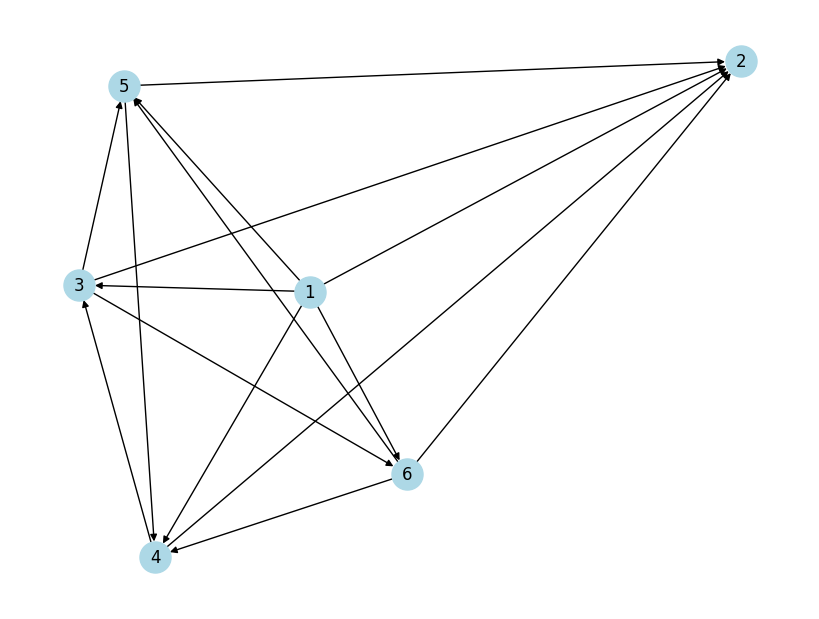

In [2]:
i.construction_graphe_majorite()
i.graphe.afficher_graphe()

Nous allons maintenant tester nos méthodes de réduction sur cette instance.

In [3]:
classement_trois_quart = inst.majority_trois_quart(i)
print("Réduction à l'aide de la règle de majorité des 3/4 :\n",classement_trois_quart)

classement_CCE = inst.condorcet_etendu(i)
print("\nRéduction à l'aide du critère de Condorcet étendu :\n",classement_CCE)

Réduction à l'aide de la règle de majorité des 3/4 :
 [1, Instance([2, 3, 4, 5, 6])]

Réduction à l'aide du critère de Condorcet étendu :
 [1, Instance([3, 4, 5, 6]), 2]


Pour tester nos fonctions de résolution, nous allons résoudre la sous instance obtenue après réduction par le critère de Condorcet étendu.

In [4]:
sous_inst = classement_CCE[1]

result_PL = inst.resolution_pl(sous_inst) 
print("Résolution de la sous instance avec la programmation dynamique \n" , inst.reconstruction_classement_PL(result_PL,sous_inst))

result_PDyn = inst.resolution_dyn(sous_inst) 
print("\nRésolution de la sous instance avec la programmation linéaire \n",inst.reconstruction_classement_PDyn(result_PDyn,sous_inst))

Set parameter TokenServer to value "132.227.118.95"
Résolution de la sous instance avec la programmation dynamique 
 [3, 6, 5, 4]

Résolution de la sous instance avec la programmation linéaire 
 [3, 6, 5, 4]


Afin d'automatiser le processus, nous avons implémenté une fonction permettant d'appliquer ou non une méthode de décomposition (ou les deux) et de résoudre l'instance.

Nous allons d'abord tester la programmation linéaire.

In [5]:
res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation linéaire sans réduction : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majority_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=inst.majority_trois_quart)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majority_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])


Résolution de l'instance avec la programmation linéaire sans réduction : 
 temps de résolution :  0.005471600999999993 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation linéaire avec 3/4 :
 temps de résolution :  0.003611911000000134 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation linéaire avec CCE :
 temps de résolution :  0.002290872999999749 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : 
 temps de résolution :  0.002138193000001287 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : 
 temps de résolution :  0.002443260999999808 
 classement :  [1, 3, 6, 5, 4, 2]


Puis, nous testons la programmation dynamique.

In [6]:
res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation dynamique sans réduction \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majority_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=inst.majority_trois_quart)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majority_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])



Résolution de l'instance avec la programmation dynamique sans réduction 
 temps de résolution :  0.0004753549999998441 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation dynamique avec 3/4 :
 temps de résolution :  0.0002806830000006144 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation dynamique avec CCE :
 temps de résolution :  0.00017948799999967235 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : 
 temps de résolution :  0.0001700059999993897 
 classement :  [1, 3, 6, 5, 4, 2]

Résolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : 
 temps de résolution :  0.00018793699999974933 
 classement :  [1, 3, 6, 5, 4, 2]


### 2. Résolution d'instances générées (modèle de Mallows)

Dans cette deuxième partie, nous utilisons le modèle de Mallows pour générer des instances. Le code pour travailler avec le modèle de Mallows est issu de github : https://github.com/ekhiru/top-k-mallows.

In [7]:
import numpy as np
import sys
sys.path.append("top-k-mallows")
import mallows_kendall as mk

n=6
m=10
s0 = np.arange(0,n)
profil_preferences = mk.sample(m=m, n=n, theta=0.5, s0=s0)
print('profil de preference : \n', profil_preferences)

nv_i = inst.Instance()

nv_i.nb_candidats = n
nv_i.nb_votants = m 

nv_i.candidats = {}
for j in range(n):
    nv_i.candidats[j+1] = str(j+1) 

nv_i.matPref = np.zeros((n+1,n+1))

for pref in profil_preferences:
    # On parcourt toutes les paires de POSITIONS (k, j)
    for k in range(1,n+1): 
        for j in range(k + 1, n+1): 
            # Le candidat à la position k est préféré au candidat à la position j
            nv_i.matPref[pref[k-1]+1, pref[j-1]+1] += 1
nv_i.init = True



profil de preference : 
 [[0 1 3 4 2 5]
 [0 1 4 5 3 2]
 [4 3 0 5 1 2]
 [5 2 3 1 4 0]
 [1 2 0 5 3 4]
 [5 0 3 1 2 4]
 [5 0 2 1 4 3]
 [0 1 4 5 3 2]
 [2 3 0 5 1 4]
 [1 4 2 0 3 5]]


Nous pouvons ensuite résoudre l'instance générée avec et sans réduction et avec nos deux méthodes de résolution, en appelant la même fonction que précédement. 

In [8]:
res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation linéaire sans réduction : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majority_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.condorcet_etendu, reduction2=inst.majority_trois_quart)
print("\nRésolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_pl, fct_reconstruction= inst.reconstruction_classement_PL, reduction1=inst.majority_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])


Résolution de l'instance avec la programmation linéaire sans réduction : 
 temps de résolution :  0.006770962000000047 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation linéaire avec 3/4 :
 temps de résolution :  0.003318614999999525 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation linéaire avec CCE :
 temps de résolution :  3.950900000049273e-05 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation linéaire avec CCE puis 3/4 : 
 temps de résolution :  9.126000000136969e-06 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation linéaire avec 3/4 puis CCE : 
 temps de résolution :  5.702600000034863e-05 
 classement :  [1, 6, 2, 5, 4, 3]


In [9]:
res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=None, reduction2=None)
print("Résolution de l'instance avec la programmation dynamique sans réduction \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majority_trois_quart, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=None)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE :\n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.condorcet_etendu, reduction2=inst.majority_trois_quart)
print("\nRésolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : \n temps de résolution : " , res[0] , "\n classement : ", res[1])

res = inst.resolution(nv_i, fct_resolution=inst.resolution_dyn, fct_reconstruction= inst.reconstruction_classement_PDyn, reduction1=inst.majority_trois_quart, reduction2=inst.condorcet_etendu)
print("\nRésolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : \n temps de résolution : " , res[0] , "\n classement : ", res[1])



Résolution de l'instance avec la programmation dynamique sans réduction 
 temps de résolution :  0.00016434700000012015 
 classement :  [1, 2, 5, 6, 3, 4]

Résolution de l'instance avec la programmation dynamique avec 3/4 :
 temps de résolution :  0.00024967000000053474 
 classement :  [1, 2, 5, 6, 3, 4]

Résolution de l'instance avec la programmation dynamique avec CCE :
 temps de résolution :  9.62799999992825e-06 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation dynamique avec CCE puis 3/4 : 
 temps de résolution :  6.042999999955612e-06 
 classement :  [1, 6, 2, 5, 4, 3]

Résolution de l'instance avec la programmation dynamique avec 3/4 puis CCE : 
 temps de résolution :  3.742999999900576e-05 
 classement :  [1, 6, 2, 5, 4, 3]
